<a href="https://colab.research.google.com/github/Naomy-Yailin/SIS420/blob/main/laboratorio2_reg_log_students_habits_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación - Regresión Logística

En este ejercicio se implementa regresión logística y se aplica al dataset *College Students Habits & Performance*.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1 Regresión Logística

En esta parte del ejercicio, se crea un modelo de regresión logística para predecir si un estudiante **aprueba o reprueba** su examen final. Se tienen datos sobre sus hábitos: horas de estudio diarias y porcentaje de asistencia. La tarea es crear un modelo de clasificación que calcule la probabilidad de aprobar (exam_score >= 60) en función de esas dos variables.

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [28]:
# Cargar datos
# Se usa pandas para leer el CSV y preparar X e y igual que el cuadernillo
# original con np.loadtxt: las dos primeras columnas son las features
# (study_hours_per_day y attendance_percentage) y la tercera es la etiqueta
# (1 = aprueba si exam_score >= 60, 0 = reprueba).
import pandas as pd

# --- AJUSTA esta ruta a donde guardaste el CSV en tu Drive ---
ruta_csv = '/content/drive/MyDrive/sis420/datasets/college_students_habits_1M.csv'

df = pd.read_csv(ruta_csv)

# Tomar solo 30000 datos
df = df.sample(n=50, random_state=42)

# Eliminar filas con nulos en las columnas que usaremos
df = df.dropna(subset=['study_hours', 'attendance', 'midterm_score'])
df['aprobado'] = (df['midterm_score'] >= 60).astype(float)
X = df[['study_hours', 'attendance']].values
y = df['aprobado'].values

print(X)
print(y)

[[  1.1876062   57.725986  ]
 [  6.1307497   86.58018   ]
 [  2.2691119   65.71012   ]
 [  4.0136757   74.98338   ]
 [  0.          42.14831   ]
 [  1.0964968   56.23412   ]
 [  5.1662946   81.98259   ]
 [  4.928175    83.61411   ]
 [  0.9955102   58.906322  ]
 [  2.621418    66.35373   ]
 [  5.02559     80.717094  ]
 [  0.26884553  52.069786  ]
 [  5.344594    85.79547   ]
 [  5.104318    84.49547   ]
 [  3.2667568   73.56025   ]
 [  4.118635    74.045265  ]
 [  2.5532084   67.56548   ]
 [  4.5127296   76.38726   ]
 [  2.7309332   70.46346   ]
 [  4.1543646   77.35208   ]
 [  2.9134305   71.169846  ]
 [  4.478866    75.979164  ]
 [  0.          39.504745  ]
 [  0.7941776   56.720474  ]
 [  2.7110317   68.385864  ]
 [  3.8394818   70.15049   ]
 [  0.19609754  51.272175  ]
 [  8.419841   100.        ]
 [  1.9852941   62.890553  ]
 [  3.1631963   70.58634   ]
 [  1.6386007   62.68332   ]
 [  3.6238697   72.47857   ]
 [  7.104126    92.22596   ]
 [  6.0396557   85.61918   ]
 [  3.547959  

### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son las horas de estudio y el porcentaje de asistencia, los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [29]:
def plotData(X, y):
    # Grafica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

Se llama a la función implementada para mostrar los datos cargados:

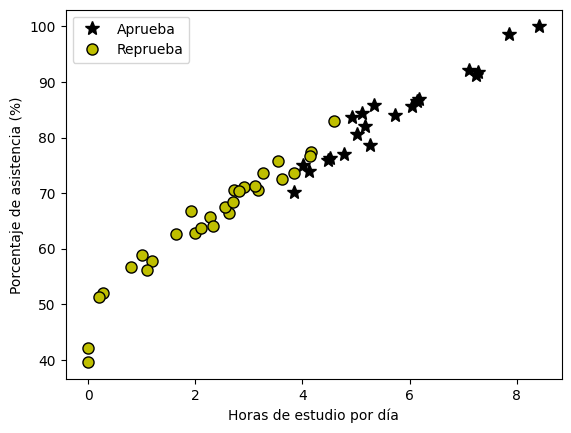

In [30]:
plotData(X, y)
pyplot.xlabel('Horas de estudio por día')
pyplot.ylabel('Porcentaje de asistencia (%)')
pyplot.legend(['Aprueba', 'Reprueba'])
pyplot.show()

### 1.2 Implementación

#### 1.2.1 Función Sigmoide

Antes de implementar la función de costo, primero se implementa la función sigmoide. La función toma como entrada la variable `z`, la cual puede ser un escalar, un vector o una matriz.

In [31]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.

    Parametros
    ----------
    z : array_like
        Puede ser un escalar, vector o matriz.

    Devuelve
    -------
    g : array_like
        Sigmoide de z. Tiene el mismo shape que z.
    """
    return 1.0 / (1.0 + np.exp(-z))

#### 1.2.2 Función de Costo y Gradiente

Ahora se implementa la función de costo y el gradiente para la regresión logística.

In [32]:
def costFunction(theta, X, y):
    """
    Calcula el costo y el gradiente para regresión logística.

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Vector de la forma (n+1, ).

    X : array_like
        Datos de entrenamiento de la forma (m, n+1).

    y : array_like
        Etiquetas de entrenamiento. Vector de la forma (m, ).

    Devuelve
    -------
    J : float
        El valor de la funcion de costo para theta.

    grad : array_like
        El gradiente de la funcion de costo con respecto a theta.
        Es un vector de la forma (n+1, ).
    """
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta))

    J = (-1.0 / m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))
    grad = (1.0 / m) * X.T.dot(h - y)

    return J, grad

# Agregar columna de unos (termino de sesgo)
m = y.size
X = np.concatenate([np.ones((m, 1)), X], axis=1)

# Probar con theta inicial = ceros
theta = np.zeros(X.shape[1])
cost, grad = costFunction(theta, X, y)
print('Costo en theta inicial (ceros): {:.3f}'.format(cost))
print('Gradiente en theta inicial:', grad)

Costo en theta inicial (ceros): 0.693
Gradiente en theta inicial: [ 0.08       -0.51965708  1.28141277]


#### 1.2.3 Descenso por el Gradiente

Se implementa el descenso por el gradiente para minimizar J(theta) iterativamente. Se prueban distintos valores de alpha para observar cómo afecta la convergencia.

theta calculado por el descenso por el gradiente: [-0.00617879  0.05718557 -0.0039165 ]
Un estudiante con 6 hrs/día de estudio y 80% de asistencia (usando el descenso por el gradiente): 1


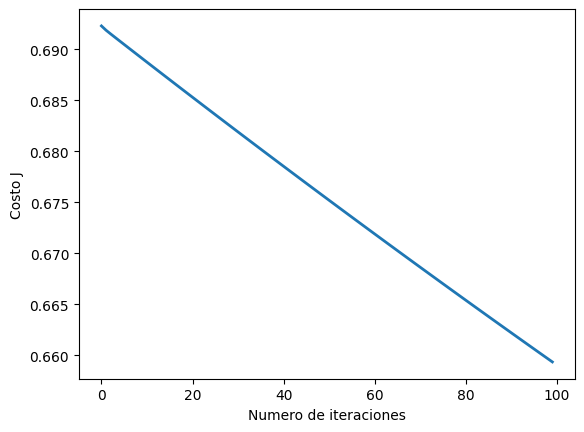

In [33]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    """
    Realiza el descenso por el gradiente para minimizar J(theta).

    Parametros
    ----------
    theta     : array (n+1,) — parametros iniciales
    X         : array (m, n+1) — datos con columna de unos
    y         : array (m,) — etiquetas 0 o 1
    alpha     : float — tasa de aprendizaje
    num_iters : int — numero de iteraciones

    Devuelve
    -------
    theta     : array (n+1,) — parametros optimizados
    J_history : list — historial del costo en cada iteracion
    """
    m = y.size
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        grad = (1.0 / m) * X.T.dot(h - y)
        theta = theta - alpha * grad
        J, _ = costFunction(theta, X, y)
        J_history.append(J)

    return theta, J_history

# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 100

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(3)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Verificar si aprueba o no con 6 horas de estudio y 80% de asistencia
X_array = [1, 6, 80]
aprueba = sigmoid(np.dot(X_array, theta))
print('Un estudiante con 6 hrs/día de estudio y 80% de asistencia (usando el descenso por el gradiente): {:.0f}'.format(aprueba))

#### 1.2.4 Optimización con `scipy`

Se usa `scipy.optimize.minimize` para encontrar los parámetros óptimos θ que minimizan la función de costo.

In [34]:
# Inicializar theta
initial_theta = np.zeros(X.shape[1])

# Optimizar
options = {'maxiter': 400}
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

theta = res.x
cost = res.fun

print('Costo en theta optimizado: {:.3f}'.format(cost))
print('Theta optimizado:', theta)

Costo en theta optimizado: 0.046
Theta optimizado: [32.01028892 15.7527616  -1.27909237]


/tmp/ipykernel_1935/1052026365.py:6: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,
/tmp/ipykernel_1935/4010246777.py:32: RuntimeWarning: divide by zero encountered in log
  J = (-1.0 / m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))


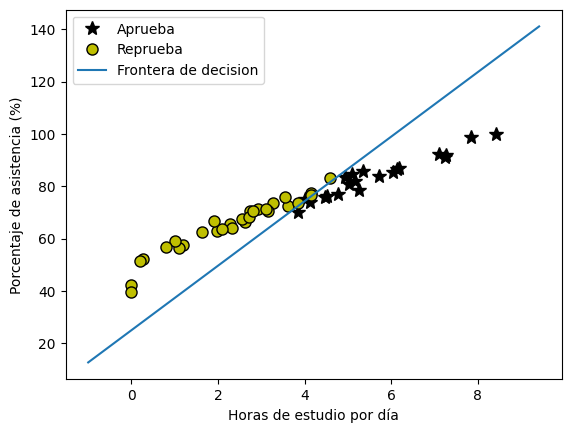

In [35]:
def plotDecisionBoundary(plotData, theta, X, y):
    # Grafica los datos y la frontera de decision aprendida.
    plotData(X[:, 1:3], y)

    # Solo se necesitan 2 puntos para definir una linea
    plot_x = np.array([X[:, 1].min() - 1, X[:, 1].max() + 1])

    # Calcular la frontera de decision
    plot_y = (-1.0 / theta[2]) * (theta[1] * plot_x + theta[0])

    pyplot.plot(plot_x, plot_y)
    pyplot.legend(['Aprueba', 'Reprueba', 'Frontera de decision'])
    pyplot.xlabel('Horas de estudio por día')
    pyplot.ylabel('Porcentaje de asistencia (%)')
    pyplot.show()

# Graficar limites
plotDecisionBoundary(plotData, theta, X, y)

#### 1.2.5 Evaluación de la regresión logística

Después de aprender los parámetros, se puede usar el modelo para predecir si un estudiante en particular aprobará. Para un estudiante con 6 horas de estudio al día y 80% de asistencia. Otra forma de evaluar la calidad de los parámetros encontrados es ver qué tan bien predice el modelo en el conjunto de entrenamiento.

In [36]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5 (es decir, si sigmoide (theta.T * x)>= 0.5, predice 1)

    Parametros
    ----------
    theta : array_like
        Parametros para regresion logistica. Un vector de la forma (n+1, ).

    X : array_like
        Datos utilizados para el calculo de las predicciones.
        La fila es el numero de los puntos para calcular las predicciones,
        y las columnas con el numero de caracteristicas.

    Devuelve
    -------
    p : array_like
        Predicciones y 0 o 1 para cada fila en X.
    """
    m = X.shape[0]  # Numero de ejemplo de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

Una vez entrenado el modelo se procede a realizar la predicción y evaluación de los resultados de predecir cuál es el valor que vota el modelo para todos los datos utilizados en el entrenamiento.

In [37]:
# Predice la probabilidad de aprobar para un estudiante con
# 6 horas de estudio por día y 80% de asistencia
prob = sigmoid(np.dot([1, 6, 80], theta))
print('Para un estudiante con 6 hrs/día de estudio y 80% de asistencia,')
print('se predice una probabilidad de aprobar de: {:.3f}'.format(prob))

# Calcular la precision en el conjunto de entrenamiento
p = predict(theta, X)
print('\nPrecisión de entrenamiento: {:.2f} %'.format(np.mean(p == y) * 100))

Para un estudiante con 6 hrs/día de estudio y 80% de asistencia,
se predice una probabilidad de aprobar de: 1.000

Precisión de entrenamiento: 98.00 %
